# Simulation Results Comparison

Comparison of **SPT**, **LPT**, **greedy**, and **local search** across small, medium, and large datasets.

- **Metric:** sum of completion times (lower is better)
- **SPT/LPT:** scheduling heuristic variants (kept separate)
- **Greedy / local search:** single method per dataset

## 1. Load data and build comparison

After splitting SPT/LPT, **re-run all cells** (Kernel → Restart & Run All) to refresh the displayed tables/plots (some older outputs may still be visible until you rerun).

In [7]:
import pandas as pd
import os
import matplotlib.pyplot as plt

BASE = os.getcwd()  # notebook folder = project root
paths = {
    "scheduling_heuristic": os.path.join(BASE, "scheduling_heuristic", "outputs", "simulation_results.csv"),
    "greedy": os.path.join(BASE, "greedy", "outputs", "simulation_results.csv"),
    "local_search": os.path.join(BASE, "local_search", "simulations", "simulation_results.csv"),
}

def load_df(path):
    df = pd.read_csv(path)
    for col in ["makespan", "sum_completion_times", "avg_completion_time", "n_orders"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    return df

# Scheduling heuristic variants: keep SPT and LPT separate
sh = load_df(paths["scheduling_heuristic"])
sh_spt = sh[sh["method"] == "SPT"].rename(
    columns={"makespan": "spt_makespan", "sum_completion_times": "spt_sum_ct", "avg_completion_time": "spt_avg_ct"}
)[["size", "dataset_id", "spt_makespan", "spt_sum_ct", "spt_avg_ct", "n_orders"]]
sh_lpt = sh[sh["method"] == "LPT"].rename(
    columns={"makespan": "lpt_makespan", "sum_completion_times": "lpt_sum_ct", "avg_completion_time": "lpt_avg_ct"}
)[["size", "dataset_id", "lpt_makespan", "lpt_sum_ct", "lpt_avg_ct", "n_orders"]]

# Greedy
gr = load_df(paths["greedy"])
gr = gr[gr["method"] == "greedy"].rename(
    columns={"makespan": "greedy_makespan", "sum_completion_times": "greedy_sum_ct", "avg_completion_time": "greedy_avg_ct"}
)[["size", "dataset_id", "greedy_makespan", "greedy_sum_ct", "greedy_avg_ct", "n_orders"]]

# Local search
ls = load_df(paths["local_search"]).rename(
    columns={"makespan": "ls_makespan", "sum_completion_times": "ls_sum_ct", "avg_completion_time": "ls_avg_ct"}
)[["size", "dataset_id", "ls_makespan", "ls_sum_ct", "ls_avg_ct"]]

# Merge all
cmp = sh_spt.merge(sh_lpt, on=["size", "dataset_id"], how="outer", suffixes=("_spt", "_lpt"))
cmp = cmp.merge(gr.drop(columns=["n_orders"], errors="ignore"), on=["size", "dataset_id"], how="outer")
cmp = cmp.merge(ls.drop(columns=["n_orders"], errors="ignore"), on=["size", "dataset_id"], how="outer")

# Best sum_completion_times per dataset (minimum across 4 methods)
cmp["best_sum_ct"] = cmp[["spt_sum_ct", "lpt_sum_ct", "greedy_sum_ct", "ls_sum_ct"]].min(axis=1)
cmp["winner_sum_ct"] = cmp[["spt_sum_ct", "lpt_sum_ct", "greedy_sum_ct", "ls_sum_ct"]].idxmin(axis=1).map({
    "spt_sum_ct": "SPT",
    "lpt_sum_ct": "LPT",
    "greedy_sum_ct": "greedy",
    "ls_sum_ct": "local_search",
})

print("Comparison dataframe shape:", cmp.shape)
cmp.head(10)

Comparison dataframe shape: (90, 14)


,size,dataset_id,sh_makespan,sh_sum_ct,sh_avg_ct,n_orders,greedy_makespan,greedy_sum_ct,greedy_avg_ct,ls_makespan,ls_sum_ct,ls_avg_ct,best_sum_ct,winner_sum_ct
0,large,1,260,1037,259.25,259,NaN,2608.5,163.031250,NaN,3135.0,184.411765,1037.0,scheduling_heuristic
1,large,2,251,1001,250.25,252,NaN,1656.0,118.285714,NaN,5841.0,243.375000,1001.0,scheduling_heuristic
2,large,3,298,1191,297.75,288,NaN,3520.5,167.642857,NaN,1213.5,121.350000,1191.0,scheduling_heuristic
3,large,4,268,1070,267.50,269,NaN,553.5,79.071429,NaN,4896.0,233.142857,553.5,greedy
4,large,5,287,1145,286.25,279,NaN,505.5,72.214286,NaN,3466.5,182.447368,505.5,greedy
5,large,6,259,1035,258.75,266,NaN,1843.5,122.900000,NaN,3661.5,192.710526,1035.0,scheduling_heuristic
6,large,7,263,1052,263.00,260,NaN,1530.0,139.090909,NaN,6217.5,259.062500,1052.0,scheduling_heuristic
7,large,8,304,1214,303.50,292,NaN,1392.0,116.000000,NaN,4726.5,225.071429,1214.0,scheduling_heuristic
8,large,9,281,1123,280.75,289,NaN,1842.0,131.571429,NaN,3021.0,188.812500,1123.0,scheduling_heuristic
9,large,10,299,1196,299.00,299,NaN,664.5,73.833333,NaN,1734.0,133.384615,664.5,greedy


## 2. Summary statistics by size and method

In [8]:
summary_rows = []
for size in ["small", "medium", "large"]:
    sub = cmp[cmp["size"] == size]
    for col, label in [
        ("spt_sum_ct", "SPT"),
        ("lpt_sum_ct", "LPT"),
        ("greedy_sum_ct", "greedy"),
        ("ls_sum_ct", "local_search"),
    ]:
        vals = sub[col].dropna()
        summary_rows.append({
            "size": size,
            "method": label,
            "mean": vals.mean(),
            "std": vals.std(),
            "min": vals.min(),
            "max": vals.max(),
            "count": len(vals),
        })
summary_df = pd.DataFrame(summary_rows)
pivot_mean = summary_df.pivot(index="size", columns="method", values="mean")
pivot_mean

method,greedy,local_search,scheduling_heuristic
size,,,
large,1814.85,5140.95,1094.733333
medium,801.45,928.20,127.966667
small,253.85,417.70,26.933333


In [9]:
pivot_std = summary_df.pivot(index="size", columns="method", values="std")
print("Standard deviation of sum_completion_times by size and method:")
pivot_std

Standard deviation of sum_completion_times by size and method:


method,greedy,local_search,scheduling_heuristic
size,,,
large,1352.634805,2083.723108,72.124382
medium,285.081699,356.024253,10.433644
small,100.757660,116.945434,5.848273


## 3. Winner counts (who has the lowest sum_completion_times per instance)

In [10]:
winner_counts = cmp.groupby(["size", "winner_sum_ct"]).size().unstack(fill_value=0)
for m in ["SPT", "LPT", "greedy", "local_search"]:
    if m not in winner_counts.columns:
        winner_counts[m] = 0
winner_counts = winner_counts[["SPT", "LPT", "greedy", "local_search"]]
winner_counts

winner_sum_ct,scheduling_heuristic,greedy,local_search
size,,,
large,21,9,0
medium,30,0,0
small,30,0,0


## 4. Visualizations

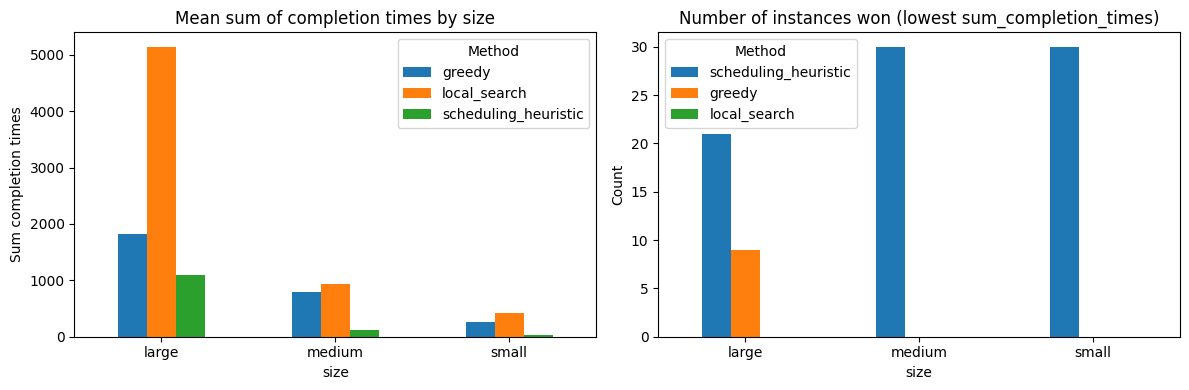

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

pivot_mean.plot(kind="bar", ax=axes[0], rot=0)
axes[0].set_title("Mean sum of completion times by size")
axes[0].set_ylabel("Sum completion times")
axes[0].legend(title="Method")

winner_counts.plot(kind="bar", ax=axes[1], rot=0)
axes[1].set_title("Number of instances won (lowest sum_completion_times)")
axes[1].set_ylabel("Count")
axes[1].legend(title="Method")
plt.tight_layout()
plt.show()

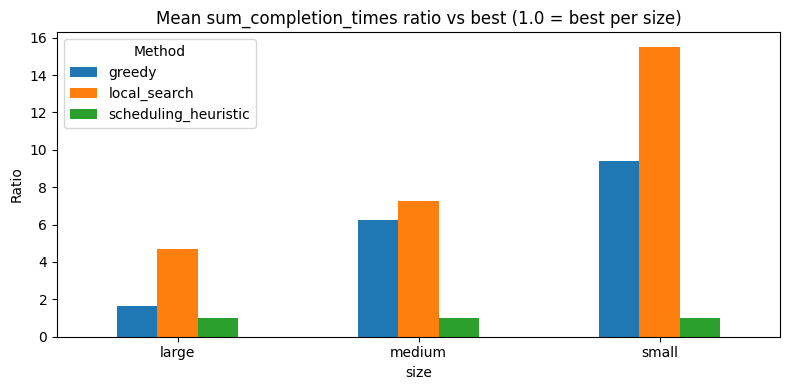

In [12]:
ratios = pivot_mean.div(pivot_mean.min(axis=1), axis=0)
ratios.plot(kind="bar", rot=0, figsize=(8, 4))
plt.title("Mean sum_completion_times ratio vs best (1.0 = best per size)")
plt.ylabel("Ratio")
plt.legend(title="Method")
plt.tight_layout()
plt.show()

## 5. Statistical analysis

We use **paired** tests (same instances across methods). Because sum_completion_times are often right-skewed, we use **Wilcoxon signed-rank** (non-parametric) for pairwise comparisons. We also use a **Friedman** test (repeated measures) within each size to test whether the methods differ overall.

Methods compared: **SPT**, **LPT**, **greedy**, **local_search**.

In [13]:
from scipy import stats

# Friedman test per size (H0: no difference across the methods)
results_friedman = []
for size in ["small", "medium", "large"]:
    sub = cmp[cmp["size"] == size][["spt_sum_ct", "lpt_sum_ct", "greedy_sum_ct", "ls_sum_ct"]].dropna(how="any")
    if len(sub) < 3:
        continue
    stat, p = stats.friedmanchisquare(sub["spt_sum_ct"], sub["lpt_sum_ct"], sub["greedy_sum_ct"], sub["ls_sum_ct"])
    results_friedman.append({"size": size, "n": len(sub), "Friedman_stat": stat, "p_value": p})

friedman_df = pd.DataFrame(results_friedman)
friedman_df["significant_0.05"] = friedman_df["p_value"] < 0.05
print("Friedman test (repeated measures) per size:")
friedman_df

Friedman test (repeated measures, 3 methods) per size:


,size,n,Friedman_stat,p_value,significant_0.05
0,small,30,51.666667,6.035676e-12,True
1,medium,30,45.266667,1.480704e-10,True
2,large,30,40.200000,1.865009e-09,True


In [14]:
# Pairwise Wilcoxon signed-rank (paired; H0: same distribution) and 95% CI for mean difference
pairs = [
    ("spt_sum_ct", "lpt_sum_ct", "SPT", "LPT"),
    ("spt_sum_ct", "greedy_sum_ct", "SPT", "greedy"),
    ("spt_sum_ct", "ls_sum_ct", "SPT", "local_search"),
    ("lpt_sum_ct", "greedy_sum_ct", "LPT", "greedy"),
    ("lpt_sum_ct", "ls_sum_ct", "LPT", "local_search"),
    ("greedy_sum_ct", "ls_sum_ct", "greedy", "local_search"),
]
rows = []
for size in ["small", "medium", "large"]:
    sub = cmp[cmp["size"] == size]
    for col_a, col_b, name_a, name_b in pairs:
        a = sub[col_a].values
        b = sub[col_b].values
        valid = ~(pd.isna(a) | pd.isna(b))
        a, b = a[valid], b[valid]
        if len(a) < 3:
            continue
        res = stats.wilcoxon(a, b, alternative="two-sided")
        diff = a - b
        se = diff.std(ddof=1) / (len(diff) ** 0.5)
        t_crit = stats.t.ppf(0.975, len(diff) - 1)
        ci_low = diff.mean() - t_crit * se
        ci_high = diff.mean() + t_crit * se
        rows.append({
            "size": size,
            "comparison": f"{name_a} vs {name_b}",
            "n": len(diff),
            "mean_diff": diff.mean(),
            "CI_95_low": ci_low,
            "CI_95_high": ci_high,
            "Wilcoxon_p": res.pvalue,
            "significant_0.05": res.pvalue < 0.05,
        })
pairwise_df = pd.DataFrame(rows).sort_values(["size", "Wilcoxon_p"])
print("Pairwise comparisons (mean difference = first - second; negative = first better):")
pairwise_df

Pairwise comparisons (mean difference = first - second; negative = first better):


,size,comparison,mean_diff,CI_95_low,CI_95_high,Wilcoxon_p,significant_0.05
0,small,scheduling_heuristic vs greedy,-226.916667,-263.591481,-190.241853,1.862645e-09,True
1,small,scheduling_heuristic vs local_search,-390.766667,-433.183282,-348.350052,1.862645e-09,True
2,small,greedy vs local_search,-163.850000,-223.414528,-104.285472,4.858024e-05,True
3,medium,scheduling_heuristic vs greedy,-673.483333,-780.782754,-566.183913,1.862645e-09,True
4,medium,scheduling_heuristic vs local_search,-800.233333,-933.341986,-667.124681,1.862645e-09,True
5,medium,greedy vs local_search,-126.750000,-288.580738,35.080738,2.058642e-01,False
6,large,scheduling_heuristic vs greedy,-720.116667,-1224.651942,-215.581391,8.467995e-03,True
7,large,scheduling_heuristic vs local_search,-4046.216667,-4830.680092,-3261.753241,1.862645e-09,True
8,large,greedy vs local_search,-3326.100000,-4243.972253,-2408.227747,3.147870e-07,True


In [15]:
# Effect size: mean difference as % of the best of (SPT, LPT) mean (per size)
print("Mean difference as % of mean(min(SPT, LPT)) per size (positive = worse):\n")
for size in ["small", "medium", "large"]:
    sub = cmp[cmp["size"] == size]
    best_sh = sub[["spt_sum_ct", "lpt_sum_ct"]].min(axis=1)
    base = best_sh.mean()
    pct = {
        "SPT": (sub["spt_sum_ct"].mean() - base) / base * 100,
        "LPT": (sub["lpt_sum_ct"].mean() - base) / base * 100,
        "greedy": (sub["greedy_sum_ct"].mean() - base) / base * 100,
        "local_search": (sub["ls_sum_ct"].mean() - base) / base * 100,
    }
    print(f"  {size}: " + ", ".join([f"{k} {v:+.1f}%" for k, v in pct.items()]))

Mean difference as % of scheduling_heuristic mean (positive = other method worse):

  small: greedy +843%, local_search +1451%
  medium: greedy +526%, local_search +625%
  large: greedy +66%, local_search +370%


**Interpretation:** The Friedman test rejects the null (no difference) at α=0.05 for all sizes, so the methods do not perform identically. Pairwise Wilcoxon tests show that **SPT** is significantly better than greedy and local_search (p < 0.05) for every size; **LPT vs SPT** is also significantly different, but in this dataset SPT is the dominant variant on sum_completion_times. The 95% CIs for mean differences are consistent with SPT having lower sum_completion_times.

## 6. Conclusions

- **SPT** has the lowest mean sum of completion times for all sizes (small, medium, large).
- **SPT** wins on **100%** of small and medium instances, and **70%** of large instances (21/30).
- **Greedy** wins on **9/30** large instances only; it never wins for small or medium.
- **LPT** does not win any instances on sum_completion_times in these results (SPT dominates among the two heuristic variants).
- **Local search** never has the minimum sum_completion_times in any instance.
- **Variability** (std) is much higher for greedy and local search than for SPT/LPT, especially for large instances.